In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os

# Mencari file trainingSet.tar.gz di seluruh Google Drive yang terhubung
file_dicari = "trainingSet.tar.gz"
lokasi_ketemu = []

for root, dirs, files in os.walk('/content/drive/MyDrive/DL'):
    if file_dicari in files:
        lokasi_ketemu.append(os.path.join(root, file_dicari))

if lokasi_ketemu:
    print("File ketemu di sini:")
    for loc in lokasi_ketemu:
        print(loc)
else:
    print("File nggak ketemu! Pastiin lu udah 'Add Shortcut' ke MyDrive.")

File ketemu di sini:
/content/drive/MyDrive/DL/Number/trainingSet.tar.gz


In [ ]:
import os
import shutil

# 1. Path file dari hasil pencarian Anda
path_di_drive = '/content/drive/MyDrive/DL/Number/trainingSet.tar.gz'
output_dir = '/content/yolo_mnist_dataset'

# 2. Ekstrak file (dilakukan sekali saja)
if not os.path.exists('/content/trainingSet'):
    print("Sedang mengekstrak file dari Drive...")
    !tar -xzf "{path_di_drive}" -C /content/
    print("Ekstraksi selesai.")

# 3. Setup folder untuk format YOLO
os.makedirs(f'{output_dir}/images/train', exist_ok=True)
os.makedirs(f'{output_dir}/labels/train', exist_ok=True)

print("Memulai konversi ke format YOLO (tunggu sebentar)...")

# 4. Generate file .txt YOLO (Asumsi angka 0-9 ada di folder masing-masing)
source_dir = '/content/trainingSet'
for label_class in range(10):
    class_dir = os.path.join(source_dir, str(label_class))
    if not os.path.exists(class_dir): continue

    for img_name in os.listdir(class_dir):
        if img_name.endswith('.jpg'):
            # Copy gambar ke folder dataset YOLO
            src_img_path = os.path.join(class_dir, img_name)
            dst_img_path = os.path.join(output_dir, 'images/train', img_name)
            shutil.copy(src_img_path, dst_img_path)

            # Bikin file label .txt (format YOLO: class x_center y_center width height)
            # Karena ini gambar digit, kita asumsikan objek ada di tengah
            txt_name = img_name.replace('.jpg', '.txt')
            txt_path = os.path.join(output_dir, 'labels/train', txt_name)
            with open(txt_path, 'w') as f:
                f.write(f"{label_class} 0.5 0.5 1.0 1.0\n")

print("Konversi Beres! Data sudah siap untuk training.")

Sedang mengekstrak file dari Drive...
Ekstraksi selesai.
Memulai konversi ke format YOLO (tunggu sebentar)...
Konversi Beres! Data sudah siap untuk training.


In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

# 1. Buat file konfigurasi data.yaml
yaml_content = f"""
train: {output_dir}/images/train
val: {output_dir}/images/train
nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
"""
with open(f'{output_dir}/data.yaml', 'w') as f:
    f.write(yaml_content)

# 2. Mulai Training
model = YOLO('yolov8n.pt') # Menggunakan versi nano (paling cepat)
model.train(
    data=f'{output_dir}/data.yaml',
    epochs=20,
    imgsz=64,
    device=0
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_mnist_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bbd090a0e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
from google.colab import files

# Path tempat model terbaik Anda disimpan
path_model = '/content/runs/detect/train/weights/best.pt'

print("Mempersiapkan unduhan...")
files.download(path_model)

Mempersiapkan unduhan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sedang memproses gambar dengan Auto-Crop Magic...
Auto-Crop Berhasil! Gambar udah di-crop mepet dan dibuat presisi.

HASIL DETEKSI YOLO (SETELAH AUTO-CROP):
KETEMU! Ini adalah angka : [ 4 ]
Tingkat keyakinan model  : 88.88%
KETEMU! Ini adalah angka : [ 2 ]
Tingkat keyakinan model  : 78.68%



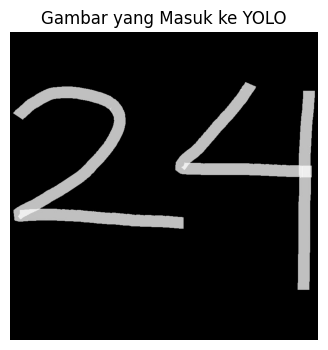

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Pastikan model dan gambar lu ada
model_path = '/content/runs/detect/train/weights/best.pt'
path_foto = '/24.jpg'

if not os.path.exists(model_path):
    print(f"Waduh, model nggak ketemu di: {model_path}")
elif not os.path.exists(path_foto):
    print(f"Foto '{path_foto}' nggak ketemu! Pastiin udah di-upload.")
else:
    trained_model = YOLO(model_path)
    print("Sedang memproses gambar dengan Auto-Crop Magic...")

    # --- AUTO-CROP & SQUARE MAGIC ---
    img = cv2.imread(path_foto)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Invert warna kalau background putih (biar angka jadi putih, background hitam)
    if np.mean(gray) > 127:
        gray = cv2.bitwise_not(gray)
        img = cv2.bitwise_not(img)

    # 2. Thresholding biar garisnya solid
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    # 3. Cari kontur (tepian) dari angka lu
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Cari bounding box (kotak) yang paling luar dari seluruh kontur angka
        x_min, y_min = img.shape[1], img.shape[0]
        x_max, y_max = 0, 0

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            x_min = min(x_min, x)
            y_min = min(y_min, y)
            x_max = max(x_max, x + w)
            y_max = max(y_max, y + h)

        # Kasih padding (jarak aman pinggiran) misal 8 pixel biar nggak potong garis
        pad = 8
        x_min = max(0, x_min - pad)
        y_min = max(0, y_min - pad)
        x_max = min(img.shape[1], x_max + pad)
        y_max = min(img.shape[0], y_max + pad)

        # Crop gambarnya jadi mepet
        img_cropped = img[y_min:y_max, x_min:x_max]

        # 4. Bikin gambarnya jadi Kotak (Square) biar YOLO nggak bikin angkanya gepeng
        h_c, w_c = img_cropped.shape[:2]
        size = max(h_c, w_c) # Ambil sisi terpanjang

        # Bikin kanvas hitam baru bentuk persegi
        square_img = np.zeros((size, size, 3), dtype=np.uint8)

        # Taruh angka yang udah di-crop tepat di tengah-tengah kanvas
        y_offset = (size - h_c) // 2
        x_offset = (size - w_c) // 2
        square_img[y_offset:y_offset+h_c, x_offset:x_offset+w_c] = img_cropped

        # Simpan sementara untuk dites
        path_tes = '/content/angka_autocrop.png'
        cv2.imwrite(path_tes, square_img)
        print("Auto-Crop Berhasil! Gambar udah di-crop mepet dan dibuat presisi.\n")

        # --- PREDIKSI ---
        results = trained_model.predict(source=path_tes, save=False, verbose=False, conf=0.15)
        kotak_deteksi = results[0].boxes

        print("="*40)
        print("HASIL DETEKSI YOLO (SETELAH AUTO-CROP):")
        print("="*40)

        if len(kotak_deteksi) == 0:
            print("WADUH: Model masih ragu. Ketebalan garis mungkin ngaruh banget.")
        else:
            for box in kotak_deteksi:
                id_kelas = int(box.cls[0].item())
                nama_kelas = trained_model.names[id_kelas]
                akurasi = round(box.conf[0].item() * 100, 2)

                print(f"KETEMU! Ini adalah angka : [ {nama_kelas} ]")
                print(f"Tingkat keyakinan model  : {akurasi}%")
        print("="*40 + "\n")

        # Tampilin gambarnya biar lu bisa liat perbandingan potongannya
        plt.figure(figsize=(4,4))
        plt.title("Gambar yang Masuk ke YOLO")
        plt.imshow(cv2.cvtColor(square_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

    else:
        print("Gagal: Nggak nemu goresan angka apa-apa di gambar ini.")